# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

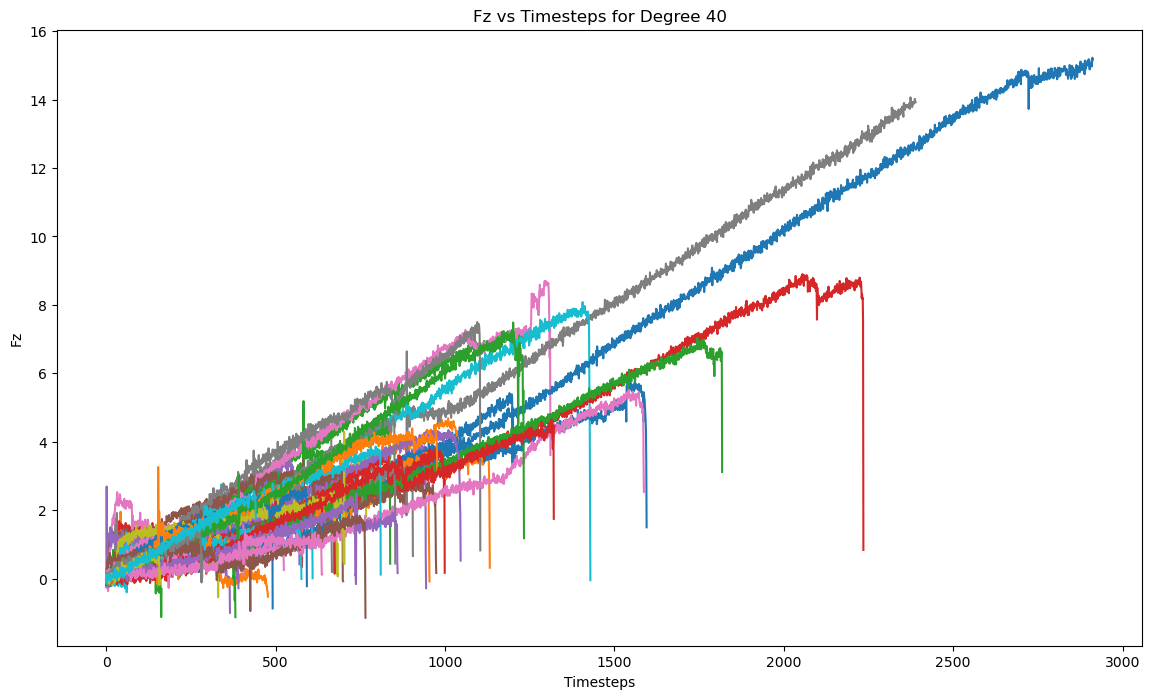

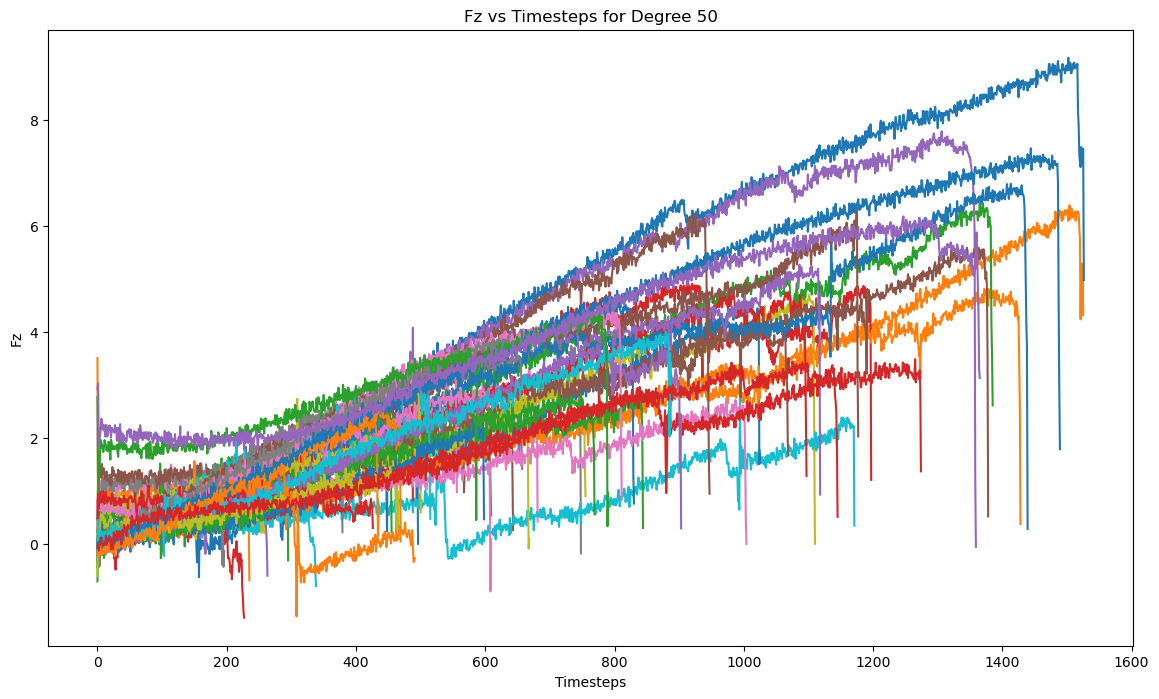

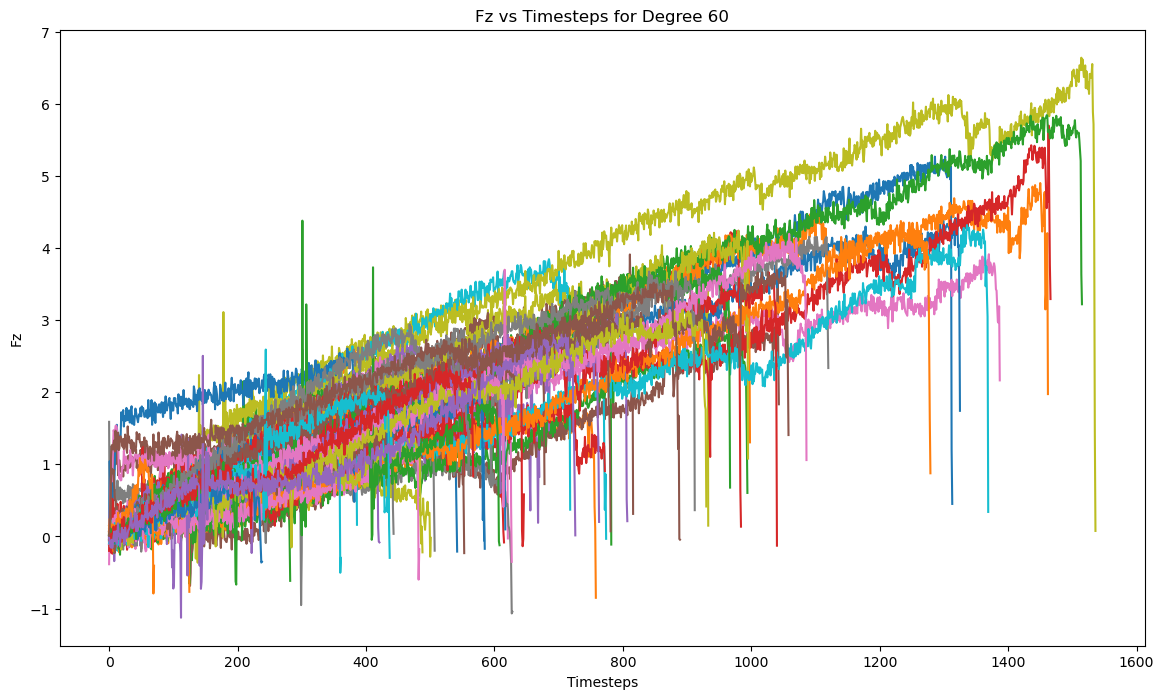

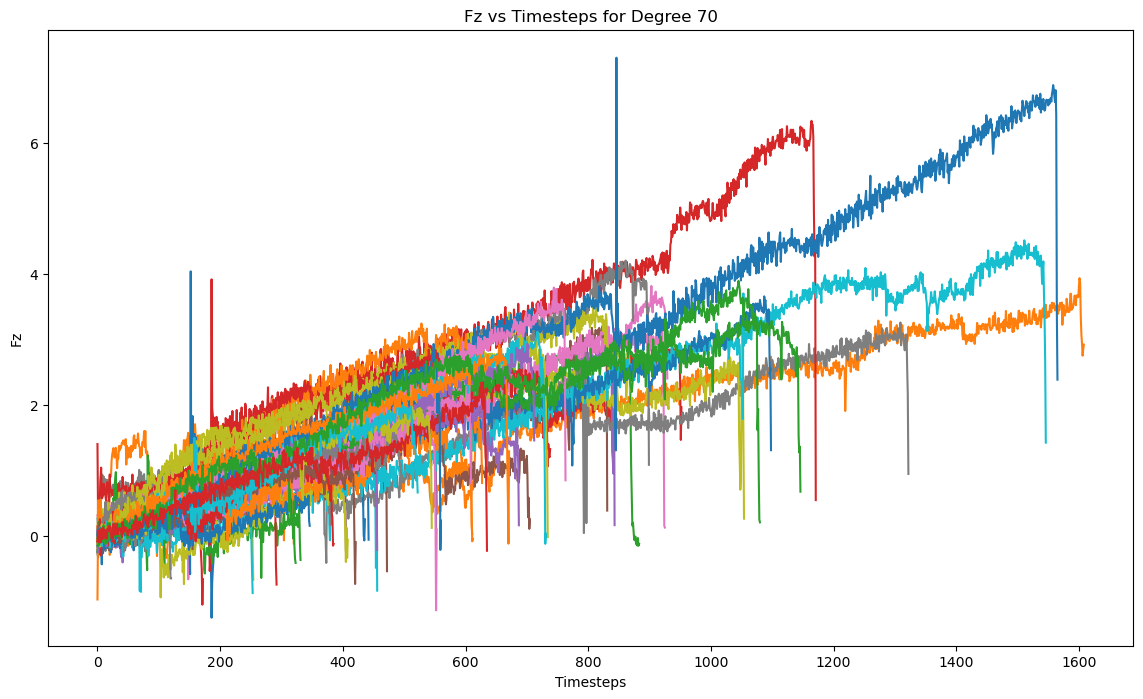

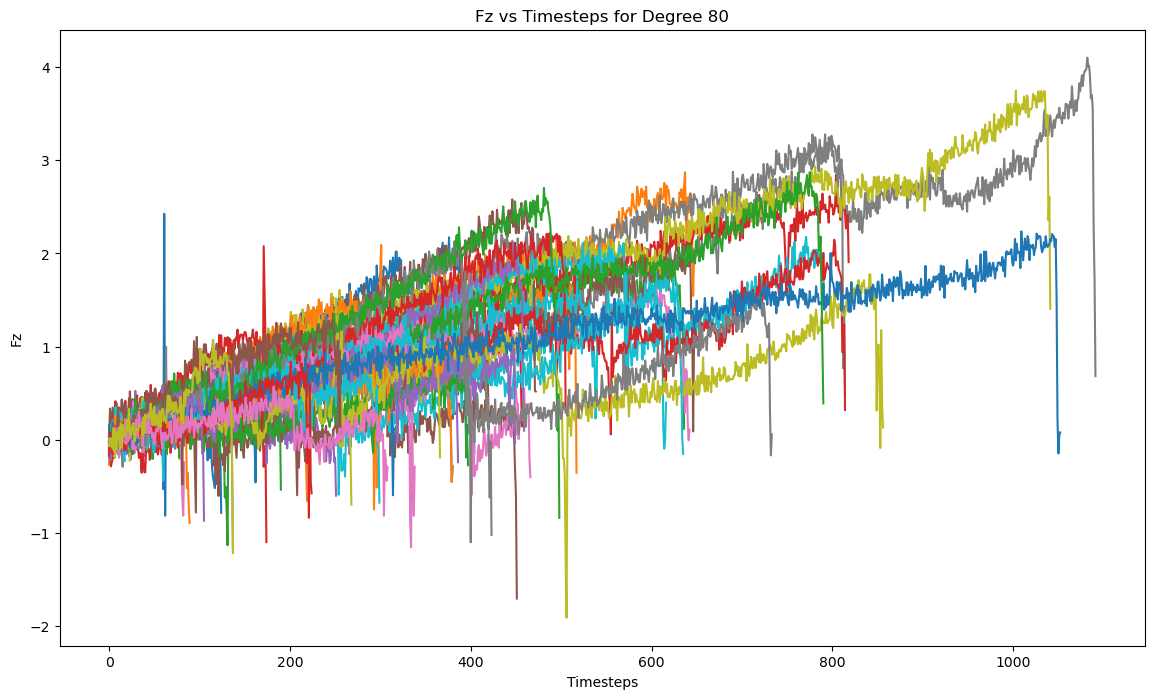

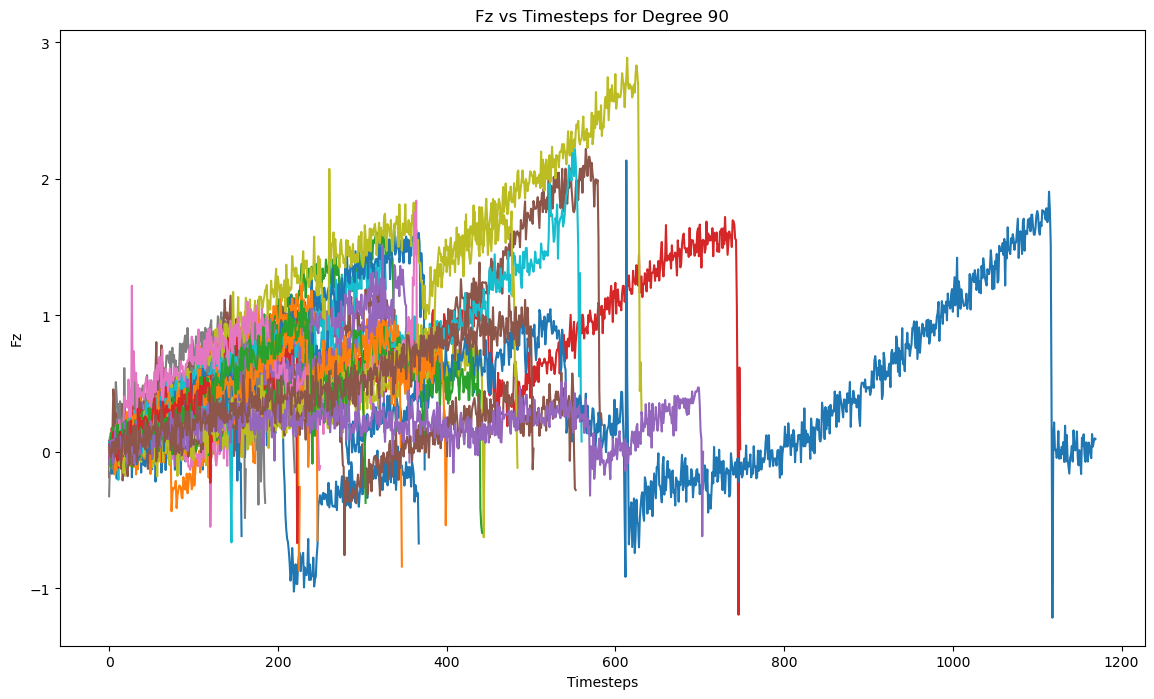

Degree: 40, Average Maximum Fz: 3.8430880228678395, Standard Deviation: 2.914849869168321
Degree: 50, Average Maximum Fz: 3.4893036984174683, Standard Deviation: 1.884432783657779
Degree: 60, Average Maximum Fz: 2.9220608304726956, Standard Deviation: 1.2952861160164229
Degree: 70, Average Maximum Fz: 2.2542399946848555, Standard Deviation: 1.3746729695292856
Degree: 80, Average Maximum Fz: 1.556229989434366, Standard Deviation: 0.8209003217946527
Degree: 90, Average Maximum Fz: 1.1740913673683446, Standard Deviation: 0.591189412972209


In [23]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Function to import and plot the data
def import_and_plot_data():
    # Define the rock names
    rock_names = ['Asphalt', 'Kalkstein', 'Lavarock', 'MatrixBrekzie', 'Schieferstein', 'Sediment']  # Add more as needed
    
    # Initialize dictionary to store statistics for each degree
    statistics = {}
    
    # Loop over degrees
    for degree in [40, 50, 60, 70, 80, 90]:
        # Create a new figure for each degree
        plt.figure(figsize=(14, 8))
        
        # Initialize list to store maximum Fz values
        max_Fz_values = []
        
        # Loop over rock names
        for rock_name in rock_names:
            # Find all files for this degree and rock name
            file_pattern = f'C:\\Users\\sramc\\Documents\\01_Studium\\50_Bachelor\'s Thesis\\07_Test\\Gripper Test Microspines Angles\\{degree}\\{rock_name}_{degree}_*.csv'
            files = glob.glob(file_pattern)
            
            # Loop over each file and plot the data
            for file in files:
                # Read the CSV file into a DataFrame
                df = pd.read_csv(file)
                
                # Generate timesteps
                timesteps = range(len(df))
                
                # Plot the Fz values against the timesteps
                plt.plot(timesteps, df['Fz'], label=f"{rock_name}")
                
                # Calculate maximum Fz value and append to the list
                max_Fz_values.append(df['Fz'].max())
        
        # Calculate average maximum Fz and its standard deviation
        avg_max_Fz = sum(max_Fz_values) / len(max_Fz_values)
        std_dev_max_Fz = pd.Series(max_Fz_values).std()
        
        # Store statistics in the dictionary
        statistics[degree] = {'avg_max_Fz': avg_max_Fz, 'std_dev_max_Fz': std_dev_max_Fz}
    
        # Add labels and title to the plot
        plt.xlabel('Timesteps')
        plt.ylabel('Fz')
        plt.title(f'Fz vs Timesteps for Degree {degree}')
        #plt.legend()
        
        # Show the plot
        plt.show()
    
    return statistics

# Run the function
statistics = import_and_plot_data()

# Print the statistics
for degree, stats in statistics.items():
    print(f"Degree: {degree}, Average Maximum Fz: {stats['avg_max_Fz']}, Standard Deviation: {stats['std_dev_max_Fz']}")


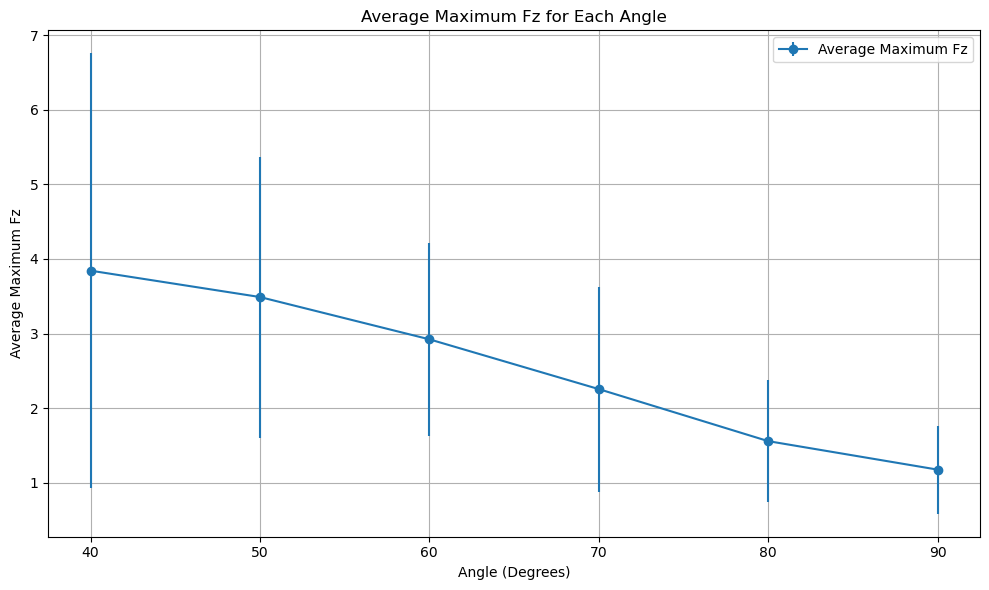

In [25]:
import matplotlib.pyplot as plt

# Function to plot the statistics for each angle
def plot_statistics(statistics):
    # Extract degrees and statistics
    degrees = list(statistics.keys())
    avg_max_Fz = [stats['avg_max_Fz'] for stats in statistics.values()]
    std_dev_max_Fz = [stats['std_dev_max_Fz'] for stats in statistics.values()]
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.errorbar(degrees, avg_max_Fz, yerr=std_dev_max_Fz, fmt='o-', label='Average Maximum Fz')
    
    # Add labels and title
    plt.title('Average Maximum Fz for Each Angle')
    plt.xlabel('Angle (Degrees)')
    plt.ylabel('Average Maximum Fz')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    # Show the plot
    plt.show()


# Plot the statistics
plot_statistics(statistics)